In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/Fraud.csv")  # path to CSV
print(df.shape)
df.head()


(179014, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [3]:
df.isnull().sum()
df['isFraud'].value_counts(normalize=True)


,proportion
isFraud,
0.0,0.999224
1.0,0.000776


In [4]:
df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1, inplace=True)


In [5]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])


In [6]:
df['orig_balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

df['amount_log'] = np.log1p(df['amount'])


In [7]:
df.drop(['oldbalanceOrg', 'newbalanceOrig',
         'oldbalanceDest', 'newbalanceDest', 'amount'], axis=1, inplace=True)


In [9]:
df.dropna(subset=['isFraud'], inplace=True)
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale Pos Weight:", scale_pos_weight)


Scale Pos Weight: 1290.8453608247423


In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


In [13]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     53662
         1.0       0.35      0.67      0.46        42

    accuracy                           1.00     53704
   macro avg       0.67      0.83      0.73     53704
weighted avg       1.00      1.00      1.00     53704



In [14]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.9779166688851382


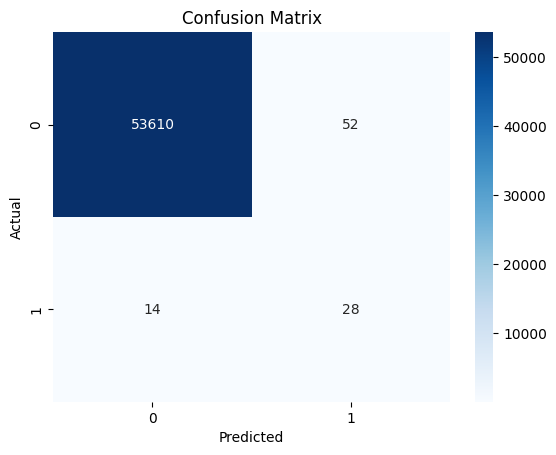

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [16]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)


Best Threshold: 0.98396665


In [17]:
y_pred_opt = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     53662
         1.0       0.71      0.52      0.60        42

    accuracy                           1.00     53704
   macro avg       0.85      0.76      0.80     53704
weighted avg       1.00      1.00      1.00     53704



In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
1,type,0.360149
2,orig_balance_change,0.279880
0,step,0.156058
4,amount_log,0.121182
3,dest_balance_change,0.082731
